In [2]:
import os
import influxtools as it
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import allantools as at

import matplotlib as mpl

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Palatino', 'Palatino Linotype', 'URW Palladio L', 'Georgia'],
})

scale = 1.25  # z.B. 1.1, 1.25, 1.5 ...

base = {
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 10,
}

mpl.rcParams.update({k: v * scale for k, v in base.items()})

it.set_token(os.environ["INFLUX_TOKEN"])  # export INFLUX_TOKEN before running

names = ('Case', 'Gain chip', 'BRF', 'Etalon')

In [3]:
start_date = '2026-07-07 08:15:00'
end_date = '2026-07-07 17:30:00'
#end_date = '2026-07-07 13:31:00'

df = it.get_data(measurement='VECSEL(next)', fields=['Case temp.', 'Gain chip temp.', 'BRF temp.', 'Etalon temp.'], start=start_date, stop=end_date)

tmp = df['Etalon temp.'].copy()

df['Etalon temp.'] = df['BRF temp.']
df['BRF temp.'] = tmp

df['time_h'] = df['time_s'] / 3600

In [4]:
for field in ['Case temp.', 'Gain chip temp.', 'BRF temp.', 'Etalon temp.']:
    set_temp = 25
    if field == 'Gain chip temp.':
        set_temp += 1.03

    label = 'dev. ' + field + ' ' + str(set_temp) + '°C'
    df[label] = df[field] - set_temp

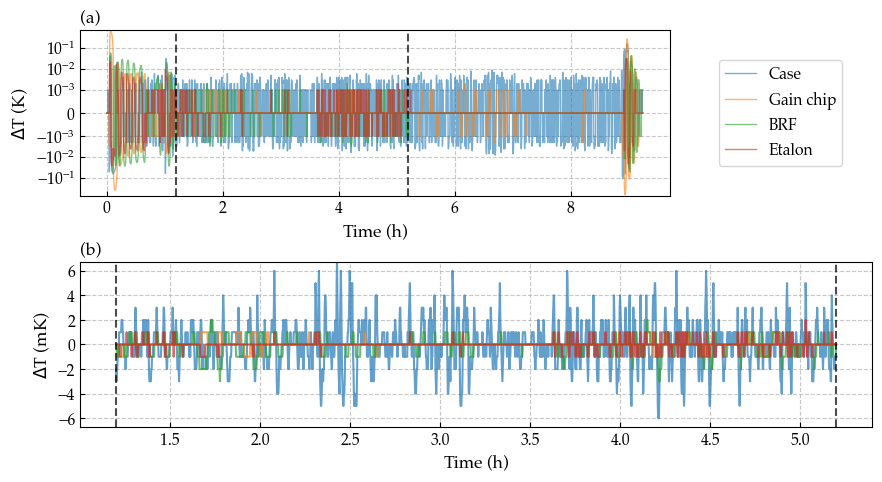

In [5]:
import matplotlib.gridspec as gridspec

limit = (1.2, 5.2)

fig = plt.figure(figsize=(9, 5))
gs = gridspec.GridSpec(2, 4, figure=fig)

# Erste Reihe: Plot 1 nimmt Spalten 0-1, Legend nimmt Spalte 2
ax1 = fig.add_subplot(gs[0, :3])
ax_legend = fig.add_subplot(gs[0, 3])

# Zweite Reihe: Plot 2 nimmt alle 3 Spalten
ax2 = fig.add_subplot(gs[1, :])

# Plot 1
for i, col in enumerate(['dev. Case temp. 25°C', 'dev. Gain chip temp. 26.03°C', 'dev. BRF temp. 25°C', 'dev. Etalon temp. 25°C']):
    s = df[['time_h', col]].dropna()
    ax1.plot(s['time_h'], s[col], label=names[i], alpha=0.6, linewidth=1)

ax1.axvline(limit[0], color='k', linestyle='dashed', alpha=0.7)
ax1.axvline(limit[1], color='k', linestyle='dashed', alpha=0.7)
ax1.set_yscale('symlog', linthresh=1e-3)
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'$\Delta$T (K)')
ax1.grid(which='both', linestyle='--', alpha=0.7)
ax1.tick_params(axis='both', which='both', direction='in')
ax1.set_title('(a)', loc='left')

# Legend in separatem Subplot
handles, labels = ax1.get_legend_handles_labels()
ax_legend.legend(handles, labels, loc='center', frameon=True)
ax_legend.axis('off')  # Achsen ausblenden

# Plot 2
for col in ['dev. Case temp. 25°C', 'dev. Gain chip temp. 26.03°C', 'dev. BRF temp. 25°C', 'dev. Etalon temp. 25°C']:
    s = df[['time_h', col]].dropna()
    s = s[(s['time_h'] > limit[0]) & (s['time_h'] < limit[1])]
    ax2.plot(s['time_h'], s[col] * 1e3, alpha=0.7)

ax2.axvline(limit[0], color='k', linestyle='dashed', alpha=0.7)
ax2.axvline(limit[1], color='k', linestyle='dashed', alpha=0.7)
ax2.set_xlabel('Time (h)')
ax2.set_ylabel(r'$\Delta$T (mK)')
ax2.set_ylim(-6.75, 6.75)
#ax2.set_yscale('symlog', linthresh=20e-1)
ax2.set_yticks(np.arange(-6, 7, 2))
ax2.grid(which='both', linestyle='--', alpha=0.7)
ax2.tick_params(axis='both', which='both', direction='in')
ax2.set_title('(b)', loc='left')

plt.tight_layout(h_pad=0.05)
plt.savefig(f'fig/temperature_timeseries.pdf', dpi=600)
plt.show()

dev. Case temp. 25°C: 30s adev = 1.36 mK
dev. Gain chip temp. 26.03°C: 30s adev = 0.16 mK
dev. BRF temp. 25°C: 30s adev = 0.40 mK
dev. Etalon temp. 25°C: 30s adev = 0.24 mK


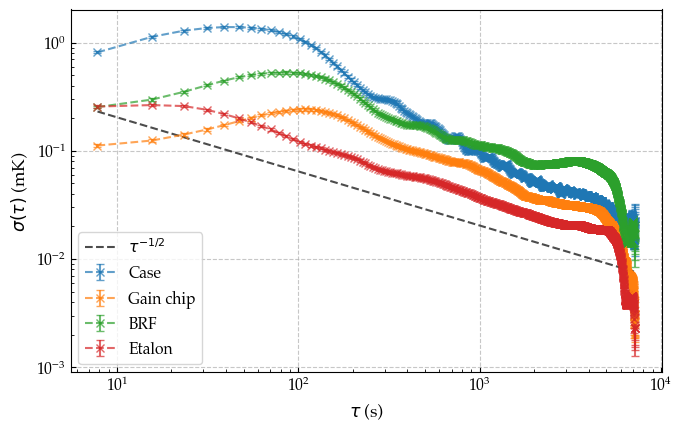

In [6]:
plt.figure(figsize=(7, 4.5))

taus = ()
adevs = []
adev_30 = []
max_adevs = []

for i, col in enumerate(['dev. Case temp. 25°C', 'dev. Gain chip temp. 26.03°C', 'dev. BRF temp. 25°C', 'dev. Etalon temp. 25°C']):
    s = df[['time_s', 'time_h', col]].dropna(subset=col)

    s = s[(s['time_h'].values > limit[0]) & (s['time_h'].values < limit[1])].reset_index(drop=True)

    mean_val = s[col].mean()
    #print(f"{col}: Mean = {mean_val:.1e} K")

    rate = 1/(np.mean(np.diff(s['time_s'])))
    tau, adev, err, n = at.oadev(data=s[col]*1e3, rate=rate, taus='all', data_type='freq')

    taus = tau

    set_temp = 25
    if col == 'dev. Gain chip temp. 26.03°C':
        set_temp += 1.03

    n = 1 # 200
    plt.errorbar(tau[:-n], adev[:-n], label=names[i], fmt='x--', alpha=0.7, markersize=6, yerr=err[:-n], capsize=3)

    anchor_tau, anchor_adev, anchor_err = tau[0], adev[0], err[0]

    adevs.append(float(adev[0]))

    adev_30.append(float(adev[np.argmin(np.abs(tau - 30))]))

    max_adev = np.max(adev)
    max_tau = tau[np.argmax(adev)]
    max_err = err[np.argmax(adev)]

    max_adevs.append(max_adev)

    #print(f"{col}: tau at max = {max_tau:.1e} s, max adev = {max_adev:.1e} mK, err at max = {max_err:.1e} mK")
    #print(f"{col}: Anchor tau = {anchor_tau:.1e} s, Anchor adev = {anchor_adev:.1e} mK, Anchor err = {anchor_err:.1e} mK")
    print(f"{col}: 30s adev = {adev_30[-1]:.2f} mK")

# reference slope line: sigma(tau) ~ tau^(0.5*a); a=-1 -> tau^-1/2 (white frequency noise)
t = np.logspace(np.log10(taus[0]), np.log10(taus[-1]), 100)
f = lambda t, a: t**(0.5 * a)

slope = -1
scale = anchor_adev*0.9 / f(anchor_tau, slope)
plt.plot(t, scale * f(t, slope), 'k--', alpha=0.7, label=r'$\tau^{-1/2}$')

plt.xscale('log')
plt.yscale('log')

#plt.ylim(2e-8, 4e-4)
#plt.ylim(2e-5, 4e-1)

plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma(\tau)$ (mK)')

plt.grid(which='major', linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='both', direction='in')

plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig(f'fig/temperature_adev.pdf', dpi=600)
plt.show()

In [7]:
dnu_dt_case = 6.2 # MHz/mK
dnu_dt_gain_chip = 30.2 # MHz/mK
#dnu_dt_gain_chip_cav = 6.2 # MHz/mK
dnu_dt_brf = 3.2 # MHz/mK
dnu_dt_etalon = 2.6 # MHz/mK

dnu_dt = np.array([dnu_dt_case, dnu_dt_gain_chip, dnu_dt_brf, dnu_dt_etalon])

for i in range(len(names)):
    freq_dev = adevs[i] * dnu_dt[i]
    freq_dev_max = max_adevs[i] * dnu_dt[i]
    freq_dev_30 = adev_30[i] * dnu_dt[i]
    print(f"{names[i]}: Frequency deviation = {freq_dev:.2f} MHz")
    print(f"{names[i]}: Maximum frequency deviation = {freq_dev_max:.2f} MHz")
    print(f"{names[i]}: 30 s frequency deviation = {freq_dev_30:.2f} MHz")

Case: Frequency deviation = 5.03 MHz
Case: Maximum frequency deviation = 8.62 MHz
Case: 30 s frequency deviation = 8.45 MHz
Gain chip: Frequency deviation = 3.38 MHz
Gain chip: Maximum frequency deviation = 7.29 MHz
Gain chip: 30 s frequency deviation = 4.75 MHz
BRF: Frequency deviation = 0.81 MHz
BRF: Maximum frequency deviation = 1.69 MHz
BRF: 30 s frequency deviation = 1.29 MHz
Etalon: Frequency deviation = 0.67 MHz
Etalon: Maximum frequency deviation = 0.69 MHz
Etalon: 30 s frequency deviation = 0.62 MHz


2.4197582503865494e-15


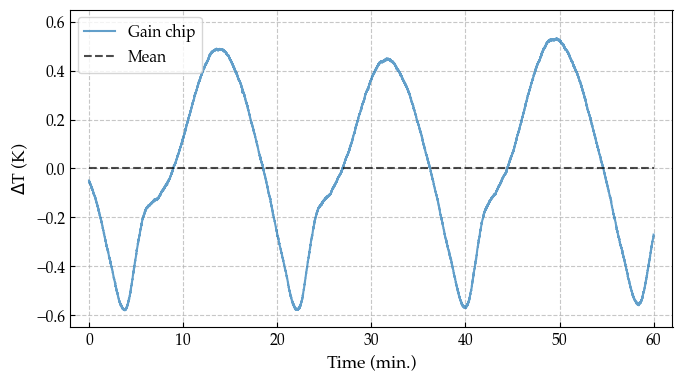

In [8]:
list = (
    '/Users/nicoschweizer/PyCharmMiscProject/PycharmProjects/Lab/Arroyo_temp_thesis/data/Influx_TEC3_21-05-26.csv',
    '/Users/nicoschweizer/PyCharmMiscProject/PycharmProjects/Lab/Arroyo_temp_thesis/data/Influx_TEC4_21-05-26.csv',
    '/Users/nicoschweizer/PyCharmMiscProject/PycharmProjects/Lab/Arroyo_temp_thesis/data/Influx_TEC4_24-06-26.csv'
)

df_tec4 = pd.read_csv(list[2], header=0)
df_tec4['dev'] = df_tec4['value'] - df_tec4['value'].mean()
print(df_tec4['dev'].mean())

plt.figure(figsize=(7, 4))

plt.plot(df_tec4['time [s]'] / 60, df_tec4['dev'], label='Gain chip', alpha=0.7, color='tab:blue')

plt.hlines(0, xmin=df_tec4['time [s]'].min() / 60, xmax=df_tec4['time [s]'].max() / 60, color='k', linestyle='dashed', alpha=0.7, linewidth=1.5, label='Mean')

plt.xlabel('Time (min.)')
plt.ylabel(r'$\Delta$T (K)')

plt.ylim(-0.65, 0.65)
plt.xlim(-2, 62)

plt.tick_params(axis='both', which='both', direction='in', grid_linestyle='--', grid_alpha=0.7)

plt.legend(loc='upper left')
plt.grid()
plt.tight_layout()
plt.savefig(f'fig/tec4_temp_deviation.pdf', dpi=600)
plt.show()